# Experimental Reproduction Notebook

This notebook follows the report structure and mixes:
- live executions of core `src/` components (Laplace + DNN2GP kernel on a small setup),
- analysis code on saved results for longer experiments,
- direct figure loading from the repository outputs.


In [1]:
from pathlib import Path
import json
import csv
import numpy as np
import matplotlib.pyplot as plt
from IPython.display import display, Markdown

try:
    import pandas as pd
except Exception:
    pd = None

ROOT = Path('.').resolve()


def p(rel_path: str) -> Path:
    return ROOT / rel_path


def md(msg: str):
    display(Markdown(msg))


def load_csv(rel_path: str):
    fp = p(rel_path)
    if not fp.exists():
        md(f"Missing file: `{rel_path}`")
        return None
    if pd is not None:
        return pd.read_csv(fp)
    with open(fp, newline='', encoding='utf-8') as f:
        reader = csv.DictReader(f)
        rows = list(reader)
    return rows


def show_image(rel_path: str, title: str | None = None, figsize=(9, 5)):
    fp = p(rel_path)
    if not fp.exists():
        md(f"Missing file: `{rel_path}`")
        return
    img = plt.imread(fp)
    plt.figure(figsize=figsize)
    if img.ndim == 2:
        plt.imshow(img, cmap='viridis')
    else:
        plt.imshow(img)
    plt.axis('off')
    if title:
        plt.title(title)
    plt.show()


def show_npy_matrix(rel_path: str, title: str, cmap='magma'):
    fp = p(rel_path)
    if not fp.exists():
        md(f"Missing file: `{rel_path}`")
        return
    arr = np.load(fp)
    plt.figure(figsize=(6, 5))
    plt.imshow(arr, cmap=cmap, aspect='auto')
    plt.colorbar()
    plt.title(title)
    plt.tight_layout()
    plt.show()


In [2]:
# Notebook execution switches.
RUN_LIVE_EXPERIMENTS = True
RUN_ADDITIONAL_LIVE_EXPERIMENTS = False
USE_CUDA_IF_AVAILABLE = True

print('RUN_LIVE_EXPERIMENTS =', RUN_LIVE_EXPERIMENTS)
print('RUN_ADDITIONAL_LIVE_EXPERIMENTS =', RUN_ADDITIONAL_LIVE_EXPERIMENTS)


RUN_LIVE_EXPERIMENTS = True
RUN_ADDITIONAL_LIVE_EXPERIMENTS = False


## 2.3 On classification


### 2.3.1 MNIST on 0,1


Kernel shape: (300, 300)
Predictive mean shape: (300, 2)
Kernel diag mean/std: 6975.626413757417 2942.35120427116
Kernel offdiag mean/std: 1188.1809264028977 2670.3234822463264


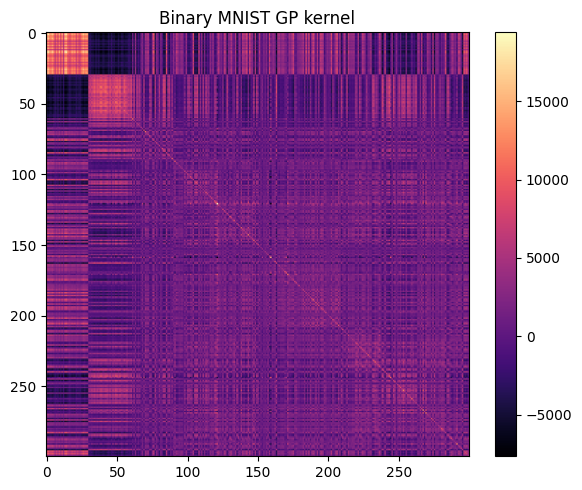

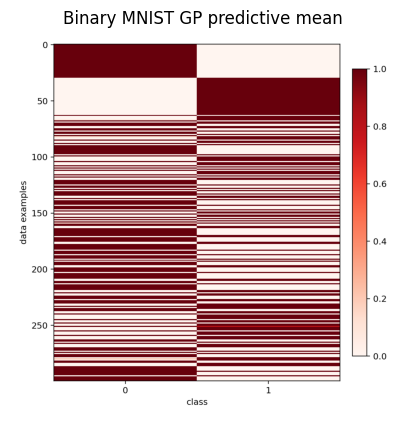

In [3]:
# analyze binary-MNIST kernel and predictive means.
K = np.load(p('results/BIN_MNIST_VI_kernel.npy'))
M = np.load(p('results/BIN_MNIST_VI_gp_predictive_mean.npy'))

print('Kernel shape:', K.shape)
print('Predictive mean shape:', M.shape)
print('Kernel diag mean/std:', float(np.diag(K).mean()), float(np.diag(K).std()))
print('Kernel offdiag mean/std:', float((K - np.diag(np.diag(K))).mean()), float((K - np.diag(np.diag(K))).std()))

plt.figure(figsize=(6,5))
plt.imshow(K, cmap='magma', aspect='auto')
plt.colorbar(); plt.title('Binary MNIST GP kernel'); plt.tight_layout(); plt.show()

show_image('figures/BIN_MNIST_VI_gp_pred_mean.png', 'Binary MNIST GP predictive mean')


#### In-notebook run: MNIST (0 vs 1) with `src/` Laplace + DNN2GP
This cell runs repository code directly from `src/` on a small MNIST subset:
- `src.neural_networks.LeNet5`
- `src.dnn2gp.compute_laplace`
- `src.dnn2gp.compute_dnn2gp_quantities`
- `src.dnn2gp.compute_kernel`


device: cuda


  0%|          | 0/6 [00:00<?, ?it/s]

 17%|█▋        | 1/6 [00:00<00:00,  5.24it/s]

 33%|███▎      | 2/6 [00:00<00:00,  6.08it/s]

 50%|█████     | 3/6 [00:00<00:00,  6.27it/s]

...

 17%|█▋        | 1/6 [00:00<00:01,  3.69it/s]

 33%|███▎      | 2/6 [00:00<00:00,  4.49it/s]

 50%|█████     | 3/6 [00:00<00:00,  4.82it/s]

 50%|█████     | 3/6 [00:00<00:00,  3.62it/s]

mean train loss (1 pass): 0.6689852777422398
post_prec dim: (43746,)
Jacobian tensor shape: (64, 2, 43746)
Kernel shape: (64, 64)


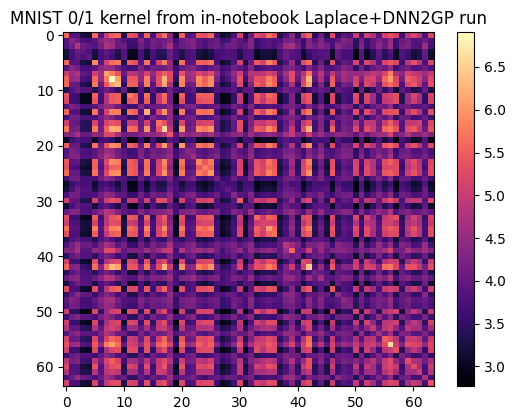

In [4]:
if RUN_LIVE_EXPERIMENTS:
    import sys
    import numpy as np
    import torch
    from torchvision import datasets, transforms
    from torch.utils.data import DataLoader, Subset

    if str(ROOT) not in sys.path:
        sys.path.insert(0, str(ROOT))

    from src.neural_networks import LeNet5
    from src.dnn2gp import compute_laplace, compute_dnn2gp_quantities, compute_kernel

    torch.manual_seed(0)
    np.random.seed(0)
    device = torch.device("cuda" if USE_CUDA_IF_AVAILABLE and torch.cuda.is_available() else "cpu")
    print("device:", device)

    tfm = transforms.Compose([transforms.ToTensor(), lambda x: x.double()])
    ds = datasets.MNIST(root=str(p("data/mnist")), train=True, download=True, transform=tfm)

    targets = ds.targets.numpy()
    idx01 = np.where((targets == 0) | (targets == 1))[0]

    train_idx = idx01[:256]
    lap_idx = idx01[:96]

    train_loader = DataLoader(Subset(ds, train_idx.tolist()), batch_size=32, shuffle=True, num_workers=0)
    lap_loader = DataLoader(Subset(ds, lap_idx.tolist()), batch_size=16, shuffle=False, num_workers=0)

    model = LeNet5(num_classes=2).to(device).double()
    opt = torch.optim.Adam(model.parameters(), lr=1e-3, weight_decay=1e-4)
    crit = torch.nn.CrossEntropyLoss()

    model.train()
    losses = []
    for xb, yb in train_loader:
        xb = xb.to(device=device, dtype=torch.double)
        yb = yb.to(device=device, dtype=torch.long)
        opt.zero_grad(set_to_none=True)
        logits = model(xb)
        loss = crit(logits, yb)
        loss.backward()
        opt.step()
        losses.append(float(loss.item()))

    post_prec = compute_laplace(model, lap_loader, prior_prec=1e-4, device=device)
    J, mean_gp, labels = compute_dnn2gp_quantities(model, lap_loader, device=device, limit=64)
    K = compute_kernel(J.numpy(), agg_type="diag")

    print("mean train loss (1 pass):", float(np.mean(losses)))
    print("post_prec dim:", tuple(post_prec.shape))
    print("Jacobian tensor shape:", tuple(J.shape))
    print("Kernel shape:", K.shape)

    plt.figure(figsize=(5.2, 4.3))
    plt.imshow(K, cmap="magma", aspect="auto")
    plt.colorbar()
    plt.title("MNIST 0/1 kernel from in-notebook Laplace+DNN2GP run")
    plt.tight_layout()
    plt.show()
else:
    print("Set RUN_LIVE_EXPERIMENTS=True to execute this MNIST run.")


### 2.3.2 CIFAR: kernel and predictive quantities


Laplace top-10 eigenvalues: [2528725.0435  435506.2483  328457.9556  196382.797   153346.6595
  128518.7364  126833.8948  116617.2182  107644.8637   92602.5497]


VI top-10 eigenvalues: [4839588.5795 2837623.396  1752156.2983 1211207.5688  908987.9881
  817518.5342  647256.7321  611694.949   461812.4257  401571.2176]


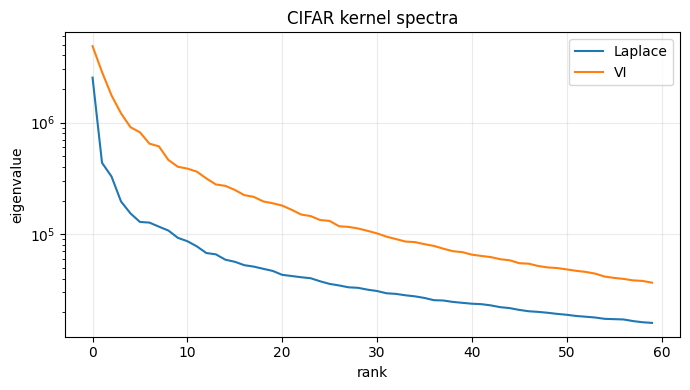

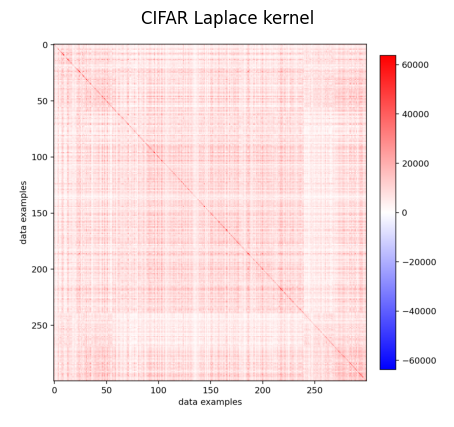

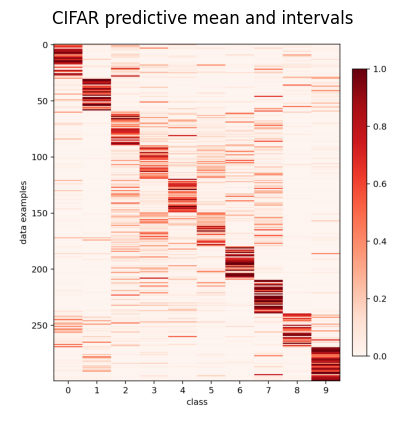

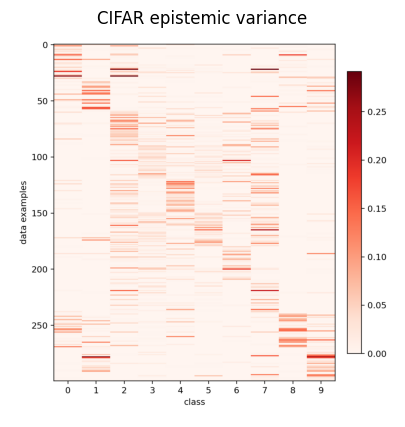

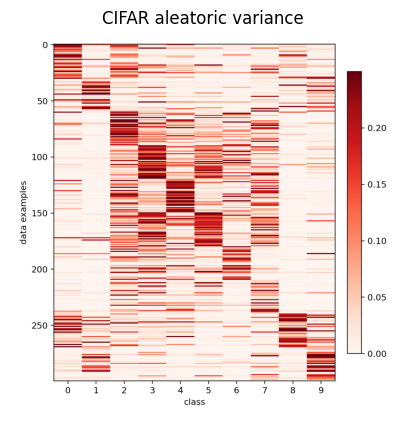

In [5]:
# compare CIFAR Laplace vs VI kernels through spectra.
K_lap = np.load(p('results/CIFAR_Laplace_kernel.npy'))
K_vi = np.load(p('results/CIFAR_VI_kernel.npy'))

for name, K in [('Laplace', K_lap), ('VI', K_vi)]:
    evals = np.linalg.eigvalsh(0.5*(K+K.T))
    evals = np.sort(np.clip(evals, 0.0, None))[::-1]
    print(name, 'top-10 eigenvalues:', np.round(evals[:10], 4))

plt.figure(figsize=(7,4))
for name, K in [('Laplace', K_lap), ('VI', K_vi)]:
    evals = np.linalg.eigvalsh(0.5*(K+K.T))
    evals = np.sort(np.clip(evals, 1e-12, None))[::-1]
    plt.plot(evals[:60], label=name)
plt.yscale('log'); plt.xlabel('rank'); plt.ylabel('eigenvalue'); plt.title('CIFAR kernel spectra'); plt.grid(alpha=0.25); plt.legend(); plt.tight_layout(); plt.show()

show_image('figures/CIFAR_Laplace_kernel.png', 'CIFAR Laplace kernel')
show_image('figures/CIFAR_Laplace_pred_mean_ste.png', 'CIFAR predictive mean and intervals')
show_image('figures/CIFAR_Laplace_var_f.png', 'CIFAR epistemic variance')
show_image('figures/CIFAR_Laplace_var_y.png', 'CIFAR aleatoric variance')


### 2.3.3 interpolation between 3 and 8, translation, rotation


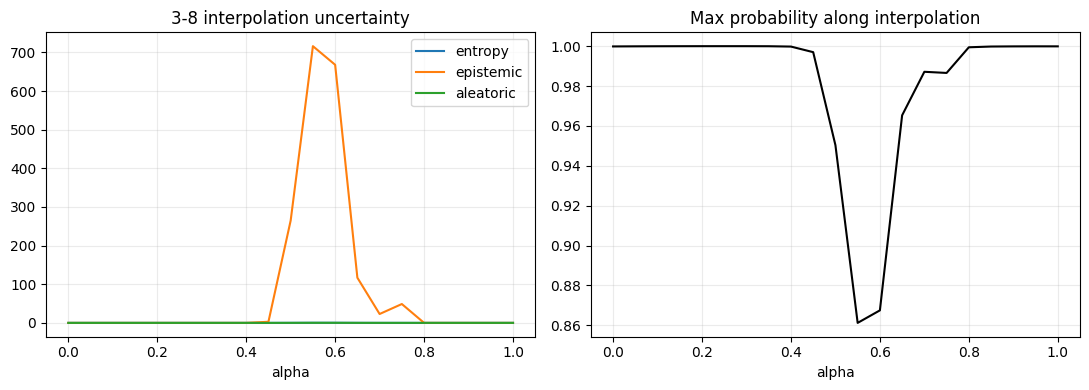

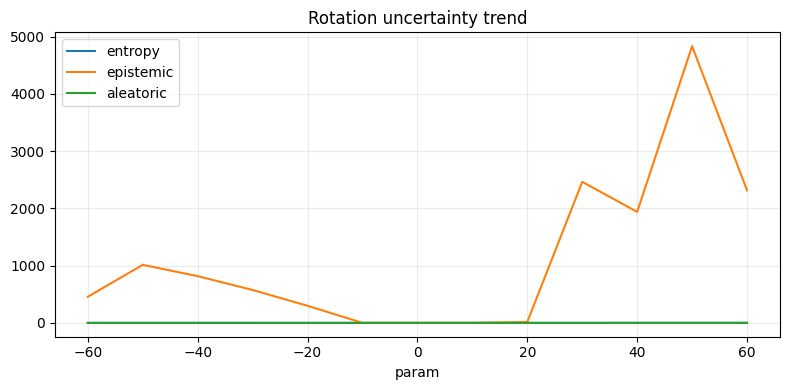

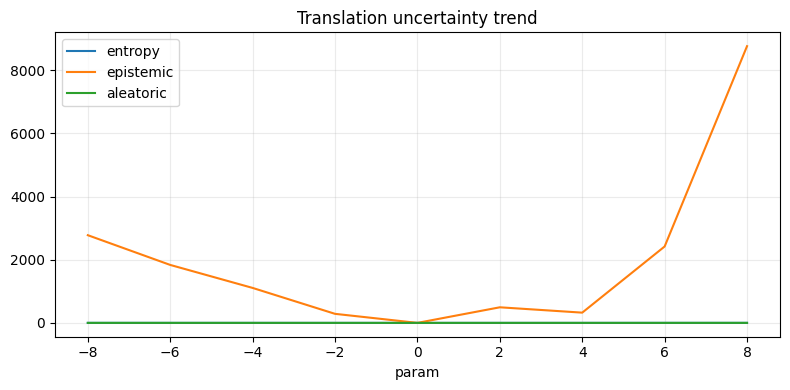

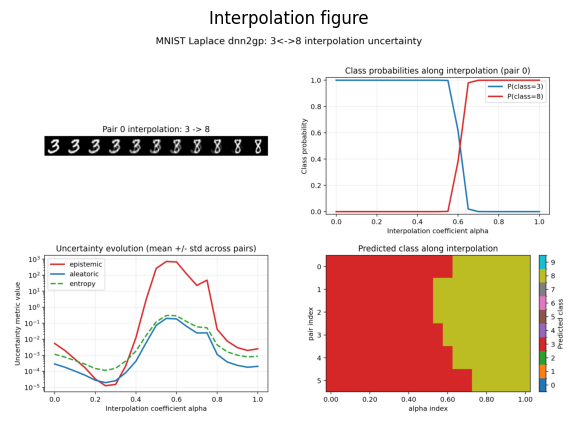

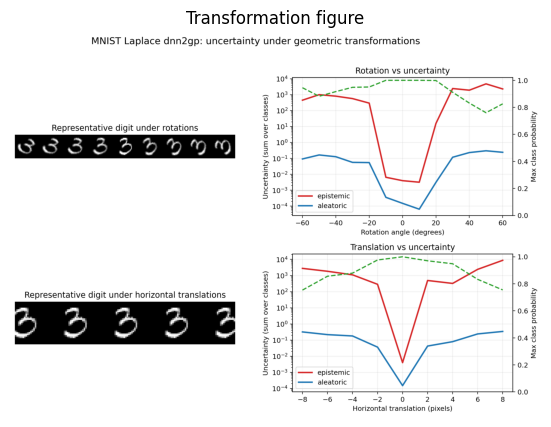

In [6]:
# summarize interpolation/transformation uncertainty trends from CSV outputs.
interp = load_csv('results/mnist_3_8_interpolation_uncertainty_metrics.csv')
transf = load_csv('results/mnist_transformation_uncertainty_metrics.csv')

if pd is not None and interp is not None:
    g = interp.groupby('alpha')[['entropy','epi_sum','alea_sum','max_prob']].mean().reset_index()
    fig, ax = plt.subplots(1,2, figsize=(11,4))
    ax[0].plot(g['alpha'], g['entropy'], label='entropy')
    ax[0].plot(g['alpha'], g['epi_sum'], label='epistemic')
    ax[0].plot(g['alpha'], g['alea_sum'], label='aleatoric')
    ax[0].set_title('3-8 interpolation uncertainty')
    ax[0].set_xlabel('alpha'); ax[0].grid(alpha=0.25); ax[0].legend()
    ax[1].plot(g['alpha'], g['max_prob'], color='black')
    ax[1].set_title('Max probability along interpolation')
    ax[1].set_xlabel('alpha'); ax[1].grid(alpha=0.25)
    plt.tight_layout(); plt.show()

if pd is not None and transf is not None:
    for tname in ['rotation', 'translation']:
        sub = transf[transf['transform_type']==tname]
        if len(sub)==0:
            continue
        g = sub.groupby('param_value')[['entropy','epi_sum','alea_sum','max_prob']].mean().reset_index()
        plt.figure(figsize=(8,4))
        plt.plot(g['param_value'], g['entropy'], label='entropy')
        plt.plot(g['param_value'], g['epi_sum'], label='epistemic')
        plt.plot(g['param_value'], g['alea_sum'], label='aleatoric')
        plt.title(f'{tname.capitalize()} uncertainty trend')
        plt.xlabel('param'); plt.grid(alpha=0.25); plt.legend(); plt.tight_layout(); plt.show()

show_image('results/mnist_3_8_interpolation_uncertainty.png', 'Interpolation figure')
show_image('results/mnist_transformation_uncertainty.png', 'Transformation figure')


### 2.3.4 adversarial attacks, and vs FGSM


Attack success rate: 0.8
Mean clean->adv shifts: {'entropy_shift': 0.8188332143333332, 'epi_shift': 0.25557728700000004, 'alea_shift': 0.171966745, 'maxprob_shift': -0.35490807799999996}


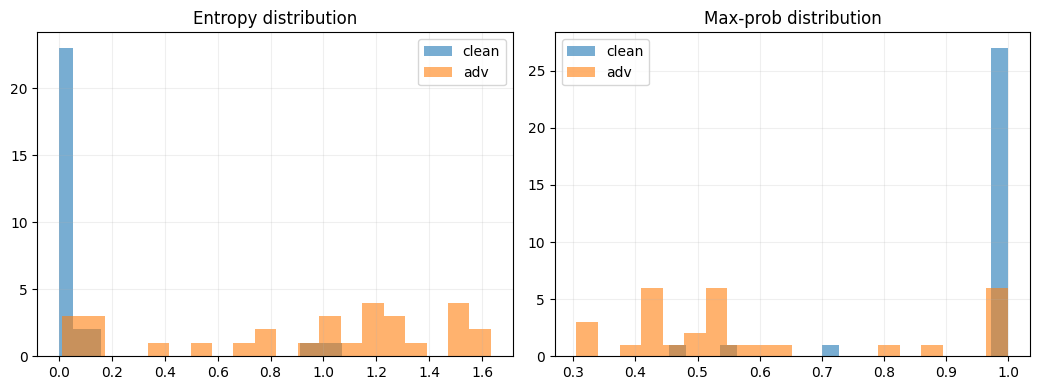

No explicit epsilon-sweep CSV files found. Current repo has fixed-epsilon runs.

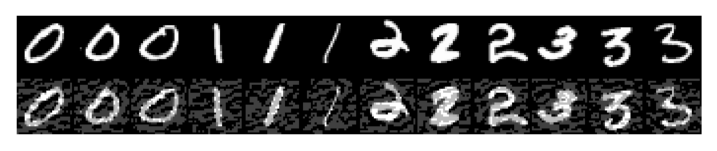

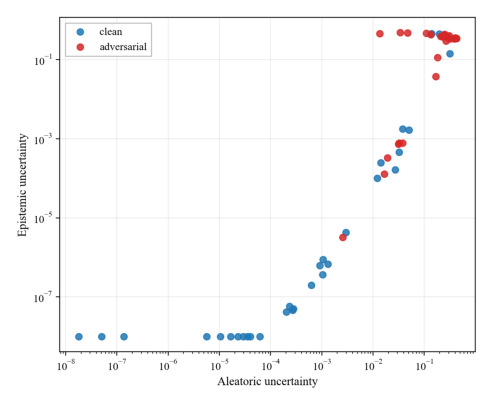

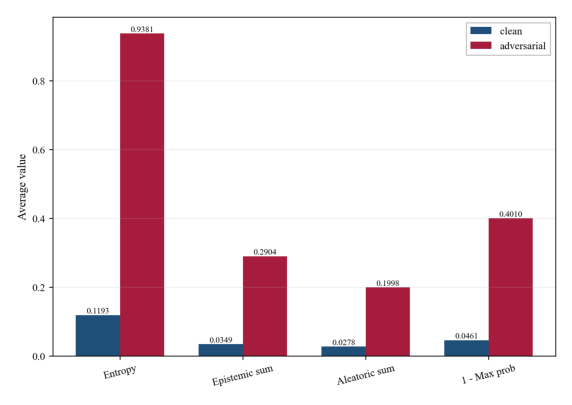

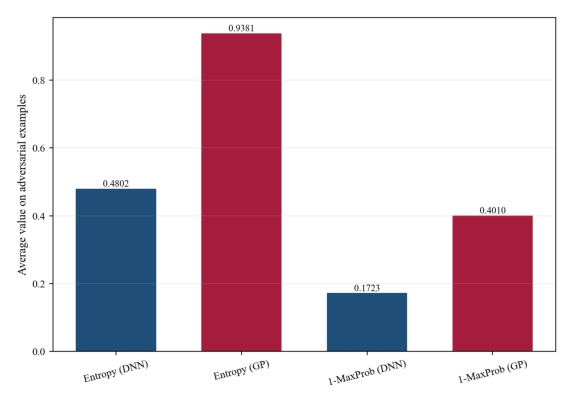

In [7]:
# summarize adversarial shifts and (if present) epsilon-sweep files.
adv = load_csv('results/mnist_adversarial_uncertainty_metrics.csv')
if pd is not None and adv is not None:
    print('Attack success rate:', float(adv['attack_success'].mean()))
    shifts = {
        'entropy_shift': float((adv['entropy_adv'] - adv['entropy_clean']).mean()),
        'epi_shift': float((adv['epi_adv'] - adv['epi_clean']).mean()),
        'alea_shift': float((adv['alea_adv'] - adv['alea_clean']).mean()),
        'maxprob_shift': float((adv['maxprob_adv'] - adv['maxprob_clean']).mean()),
    }
    print('Mean clean->adv shifts:', shifts)

    fig, ax = plt.subplots(1,2, figsize=(10.5,4))
    ax[0].hist(adv['entropy_clean'], bins=20, alpha=0.6, label='clean')
    ax[0].hist(adv['entropy_adv'], bins=20, alpha=0.6, label='adv')
    ax[0].set_title('Entropy distribution'); ax[0].legend(); ax[0].grid(alpha=0.2)
    ax[1].hist(adv['maxprob_clean'], bins=20, alpha=0.6, label='clean')
    ax[1].hist(adv['maxprob_adv'], bins=20, alpha=0.6, label='adv')
    ax[1].set_title('Max-prob distribution'); ax[1].legend(); ax[1].grid(alpha=0.2)
    plt.tight_layout(); plt.show()

# FGSM-vs-epsilon: uses files named results/mnist_adversarial_uncertainty_metrics_eps*.csv if available.
if pd is not None:
    eps_files = sorted(Path('results').glob('mnist_adversarial_uncertainty_metrics_eps*.csv'))
    if eps_files:
        rows=[]
        for f in eps_files:
            s=f.stem.split('eps')[-1].replace('_','.')
            try:
                eps=float(s)
            except:
                continue
            df=pd.read_csv(f)
            rows.append({'epsilon':eps,'attack_success':float(df['attack_success'].mean()),'entropy_adv':float(df['entropy_adv'].mean())})
        if rows:
            tbl=pd.DataFrame(rows).sort_values('epsilon')
            display(tbl)
            fig,ax=plt.subplots(1,2,figsize=(10,4))
            ax[0].plot(tbl['epsilon'],tbl['attack_success'],marker='o'); ax[0].set_title('Attack success vs epsilon'); ax[0].grid(alpha=0.25)
            ax[1].plot(tbl['epsilon'],tbl['entropy_adv'],marker='o'); ax[1].set_title('Adv entropy vs epsilon'); ax[1].grid(alpha=0.25)
            plt.tight_layout(); plt.show()
    else:
        md('No explicit epsilon-sweep CSV files found. Current repo has fixed-epsilon runs.')

show_image('results/adversarial_examples/mnist_adversarial_samples_clean_vs_adv.png')
show_image('results/adversarial_examples/mnist_adversarial_uncertainty_shift.png')
show_image('results/adversarial_examples/mnist_adversarial_gp_averages_clean_vs_adv.png')
show_image('results/adversarial_examples/mnist_adversarial_gp_vs_dnn_confidence.png')


### 2.3.5 Coverage experiments: Fashion-MNIST


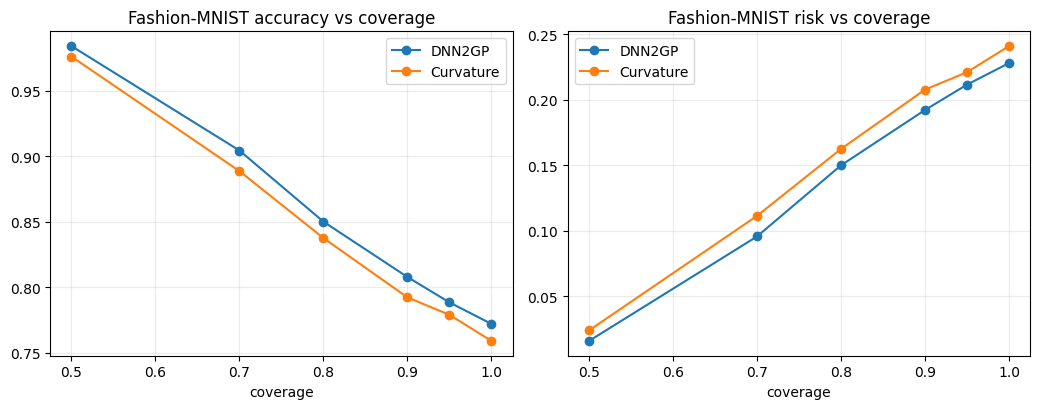

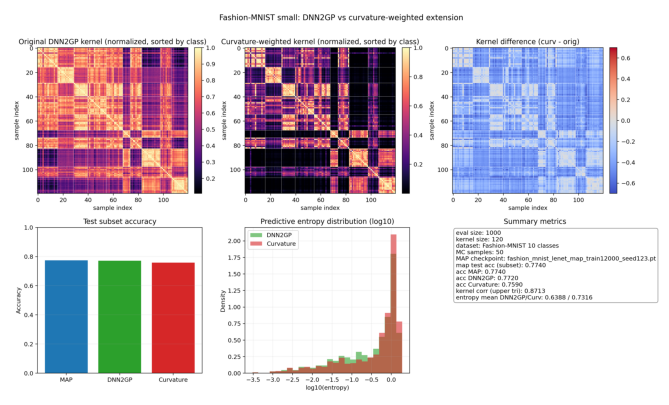

In [8]:
# compute risk/coverage on Fashion-MNIST from saved predictions + uncertainty.
arr_path = p('curvature_extension_results/fashion_mnist_curvature_extension/predictions_and_metrics_arrays.npz')
if arr_path.exists():
    arr = np.load(arr_path)
    y = arr['y_true']

    def coverage_curve(pred, unc, coverages=np.array([1.0,0.95,0.9,0.8,0.7,0.5])):
        order = np.argsort(unc)  # least uncertain kept
        n=len(pred)
        acc=[]
        for c in coverages:
            k=max(1,int(np.floor(c*n)))
            idx=order[:k]
            acc.append(np.mean(pred[idx]==y[idx]))
        acc=np.array(acc)
        return coverages, acc, 1.0-acc

    cov,acc_ntk,risk_ntk=coverage_curve(arr['pred_dnn2gp'],arr['entropy_dnn2gp'])
    _,acc_curv,risk_curv=coverage_curve(arr['pred_curvature'],arr['entropy_curvature'])

    fig,ax=plt.subplots(1,2,figsize=(10.5,4.2))
    ax[0].plot(cov,acc_ntk,marker='o',label='DNN2GP'); ax[0].plot(cov,acc_curv,marker='o',label='Curvature')
    ax[0].set_title('Fashion-MNIST accuracy vs coverage'); ax[0].set_xlabel('coverage'); ax[0].grid(alpha=0.25); ax[0].legend()
    ax[1].plot(cov,risk_ntk,marker='o',label='DNN2GP'); ax[1].plot(cov,risk_curv,marker='o',label='Curvature')
    ax[1].set_title('Fashion-MNIST risk vs coverage'); ax[1].set_xlabel('coverage'); ax[1].grid(alpha=0.25); ax[1].legend()
    plt.tight_layout(); plt.show()
else:
    md('Missing Fashion-MNIST prediction arrays.')

show_image('curvature_extension_results/fashion_mnist_curvature_extension/fashion_mnist_small_dnn2gp_vs_curvature_extension.png')


## 2.4 A more geometry-aware kernel


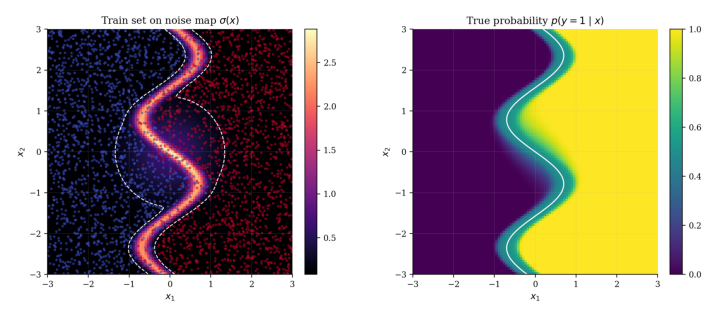

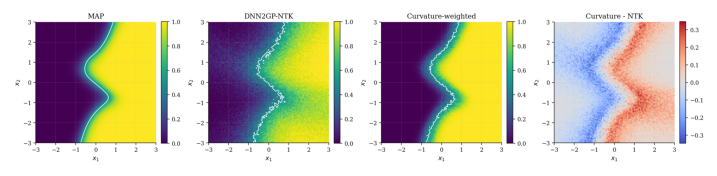

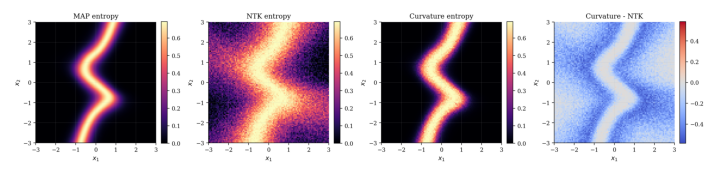

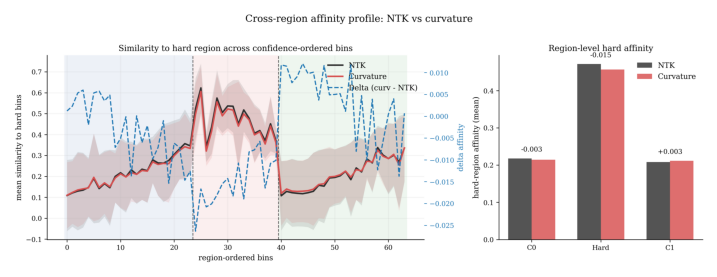

Hardband quick_take: curvature better calibrated globally and in hard region
Hardband kernel corr: 0.9967427618233262
Synthetic kernel corr: 0.9937420559261653
Synthetic center entropy diff (curv-dnn2gp): 0.01567460184185132


In [9]:
# read geometry-aware summary metrics and visualize key figures.
show_image('results/curvature_hardband_2d/dataset_and_noise_maps_neurips.png')
show_image('results/curvature_hardband_2d/predictive_probability_maps_neurips.png')
show_image('results/curvature_hardband_2d/predictive_entropy_maps_neurips.png')
show_image('results/curvature_hardband_2d/kernel_cross_region_affinity_neurips.png')

with open(p('results/curvature_hardband_2d/summary_metrics.json')) as f:
    hard=json.load(f)
with open(p('results/curvature_synthetic_2d/summary_metrics.json')) as f:
    syn=json.load(f)

print('Hardband quick_take:', hard.get('quick_take'))
print('Hardband kernel corr:', hard.get('kernel_corr_upper_tri_normalized'))
print('Synthetic kernel corr:', syn.get('kernel_corr_upper_tri_normalized'))
print('Synthetic center entropy diff (curv-dnn2gp):', syn.get('entropy_center_diff_curvature_minus_dnn2gp'))


#### Optional in-notebook run: curvature hard-band 2D (small setup)


In [10]:
if RUN_ADDITIONAL_LIVE_EXPERIMENTS:
    import sys
    import numpy as np
    import torch

    if str(ROOT) not in sys.path:
        sys.path.insert(0, str(ROOT))

    from experiments.curvature_hardband_2d.run_curvature_hardband_2d import (
        set_seed,
        resolve_device,
        build_train_set,
        sample_raw,
        BinaryMLP,
        make_loader,
        train_map,
        map_accuracy,
        sigma_fn,
    )

    set_seed(7)
    rng = np.random.default_rng(7)
    device = resolve_device("auto" if USE_CUDA_IF_AVAILABLE else "cpu")

    x_train, y_train, sigma_train, _ = build_train_set(
        n_train=600,
        hard_quantile=0.78,
        hard_fraction=0.20,
        pool_mult=5,
        rng=rng,
    )
    x_test, y_test, _, _ = sample_raw(900, rng)

    train_loader = make_loader(x_train, y_train, batch_size=64, shuffle=True)
    test_loader = make_loader(x_test, y_test, batch_size=128, shuffle=False)

    model = BinaryMLP(hidden_size=32, n_hidden=2, activation="tanh").to(device)
    train_map(
        model=model,
        train_loader=train_loader,
        test_loader=test_loader,
        device=device,
        epochs=8,
        lr=1e-3,
        weight_decay=1e-4,
    )
    acc = map_accuracy(model, test_loader, device)
    print("Tiny hard-band test accuracy:", float(acc))

    gx = np.linspace(-3.0, 3.0, 70)
    gy = np.linspace(-3.0, 3.0, 70)
    XX, YY = np.meshgrid(gx, gy)
    grid = np.column_stack([XX.ravel(), YY.ravel()])

    with torch.no_grad():
        logits = model(torch.from_numpy(grid).float().to(device))
        p1 = torch.softmax(logits, dim=1)[:, 1].cpu().numpy().reshape(XX.shape)

    sigma_map = sigma_fn(grid).reshape(XX.shape)

    fig, ax = plt.subplots(1, 2, figsize=(10, 4.2))
    im0 = ax[0].contourf(XX, YY, sigma_map, levels=25, cmap="viridis")
    ax[0].scatter(x_train[:, 0], x_train[:, 1], c=y_train, s=7, cmap="coolwarm", alpha=0.45)
    ax[0].set_title("Noise map and train points")
    fig.colorbar(im0, ax=ax[0], shrink=0.85)

    im1 = ax[1].contourf(XX, YY, p1, levels=25, cmap="coolwarm", vmin=0, vmax=1)
    ax[1].set_title("MAP predictive P(y=1)")
    fig.colorbar(im1, ax=ax[1], shrink=0.85)

    for a in ax:
        a.set_xlabel("x1")
        a.set_ylabel("x2")
    plt.tight_layout()
    plt.show()
else:
    print("Set RUN_ADDITIONAL_LIVE_EXPERIMENTS=True to execute this run.")


Set RUN_ADDITIONAL_LIVE_EXPERIMENTS=True to execute this run.


## 2.5 VOGN


### 2.5.1 VOGN predictive plots (last epoch)


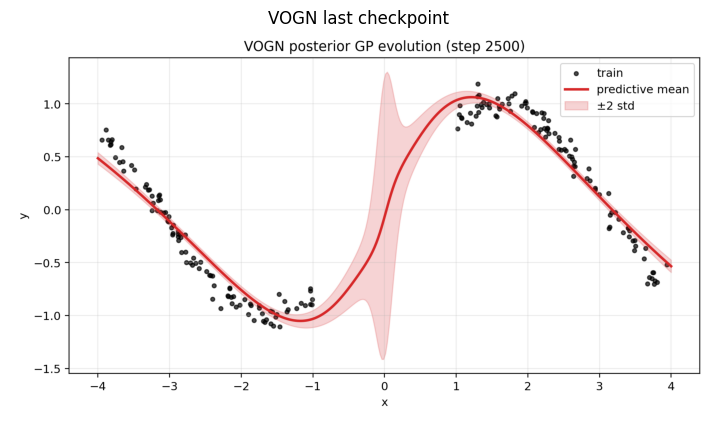

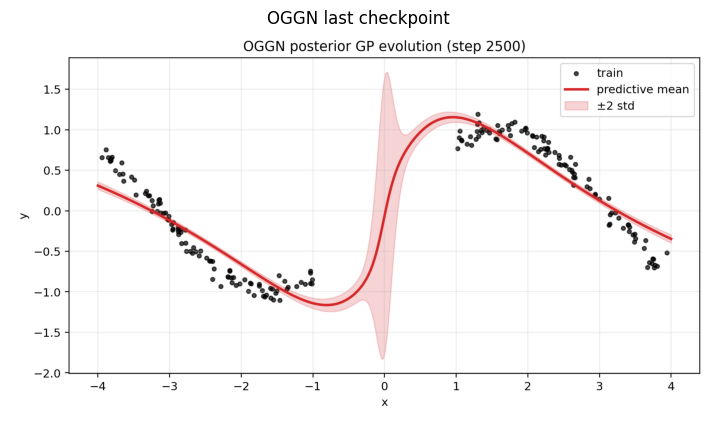

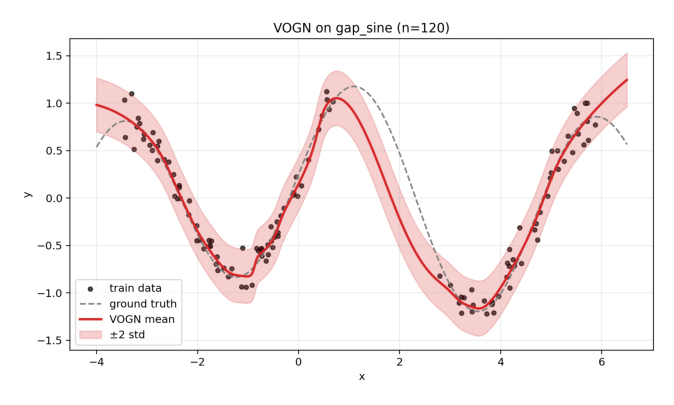

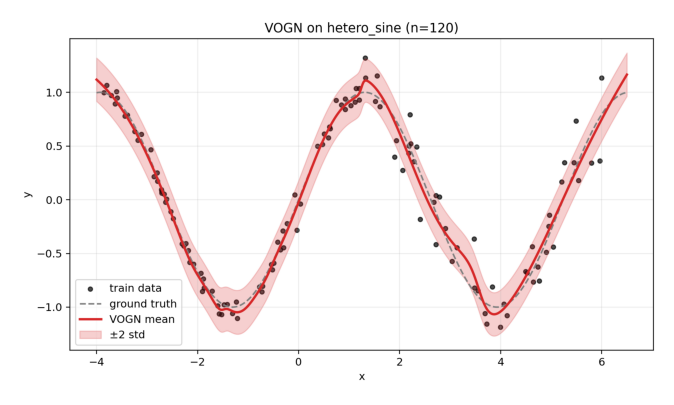

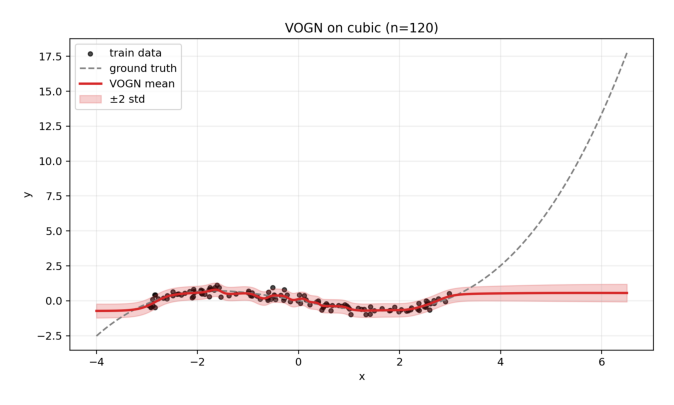

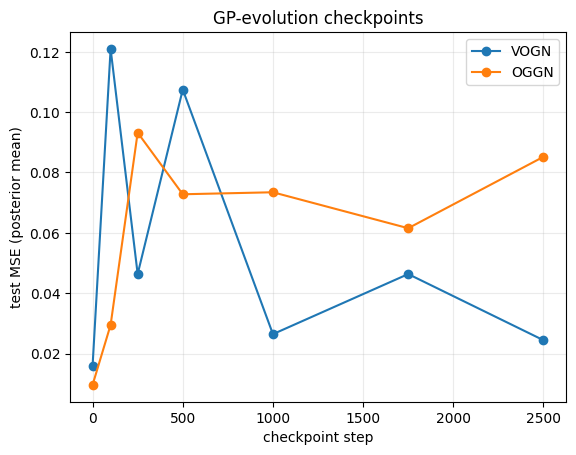

In [11]:
show_image('voggn_results/experiment1_gp_evolution/vogn/mean_variance_step_2500.png', 'VOGN last checkpoint')
show_image('voggn_results/experiment1_gp_evolution/oggn/mean_variance_step_2500.png', 'OGGN last checkpoint')
show_image('figures/vogn_gap_sine.png')
show_image('figures/vogn_hetero_sine.png')
show_image('figures/vogn_cubic.png')

# Code demo: track test MSE of posterior mean across checkpoints.
with open(p('voggn_results/experiment1_gp_evolution/metrics.json')) as f:
    m=json.load(f)
for method in ['VOGN','OGGN']:
    steps=[]; mse=[]
    for k,v in m[method].items():
        s=int(k.split('_')[-1]); steps.append(s); mse.append(v['test_mse_posterior_mean'])
    idx=np.argsort(steps); steps=np.array(steps)[idx]; mse=np.array(mse)[idx]
    plt.plot(steps,mse,marker='o',label=method)
plt.xlabel('checkpoint step'); plt.ylabel('test MSE (posterior mean)'); plt.title('GP-evolution checkpoints'); plt.grid(alpha=0.25); plt.legend(); plt.show()


### 2.5.2 Optimizer comparison


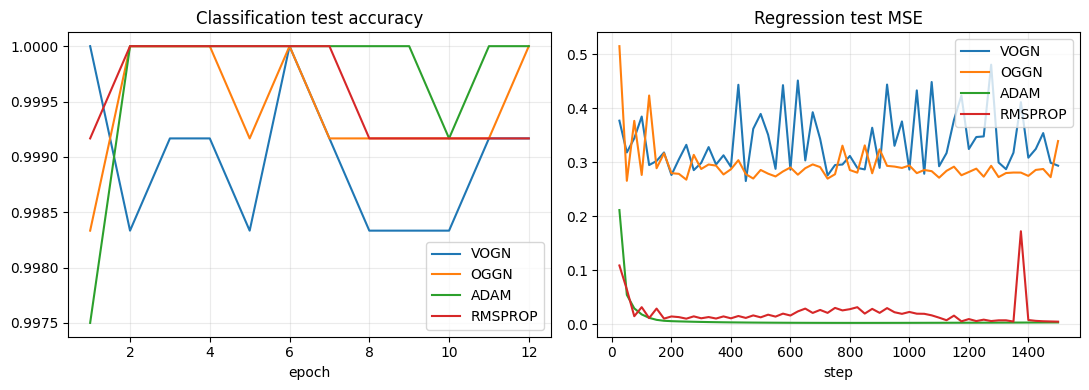

VOGN best step 450 best 0.265235861553863 final 0.29362984657712177
OGGN best step 50 best 0.26563659305700343 final 0.3392397778676709
ADAM best step 825 best 0.0026470901816829503 final 0.0034849324776505867
RMSPROP best step 1500 best 0.00491607033854013 final 0.00491607033854013


In [12]:
cl=np.load(p('voggn_results/experiment2_optimizer_comparison/classification_histories.npz'))
rg=np.load(p('voggn_results/experiment2_optimizer_comparison/regression_histories.npz'))

fig,ax=plt.subplots(1,2,figsize=(11,4))
for m in ['vogn','oggn','adam','rmsprop']:
    ax[0].plot(cl['epochs'],cl[f'{m}_test_acc'],label=m.upper())
ax[0].set_title('Classification test accuracy'); ax[0].set_xlabel('epoch'); ax[0].grid(alpha=0.25); ax[0].legend()
for m in ['vogn','oggn','adam','rmsprop']:
    ax[1].plot(rg['steps'],rg[f'{m}_test_mse'],label=m.upper())
ax[1].set_title('Regression test MSE'); ax[1].set_xlabel('step'); ax[1].grid(alpha=0.25); ax[1].legend()
plt.tight_layout(); plt.show()

# Best-vs-final summary (code-driven).
for m in ['vogn','oggn','adam','rmsprop']:
    mse=np.array(rg[f'{m}_test_mse'],dtype=float)
    best_i=int(np.argmin(mse))
    print(m.upper(), 'best step', int(rg['steps'][best_i]), 'best', float(mse[best_i]), 'final', float(mse[-1]))


### 2.5.3 Calibration curves


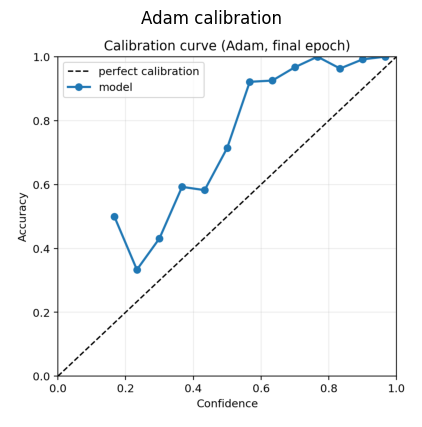

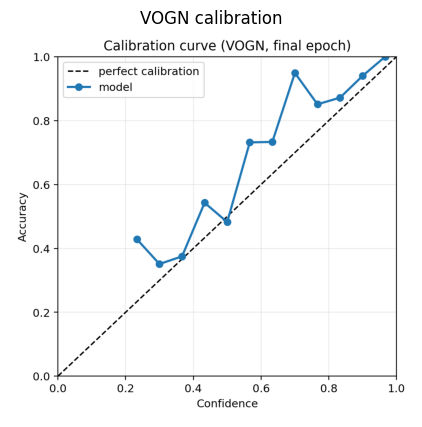

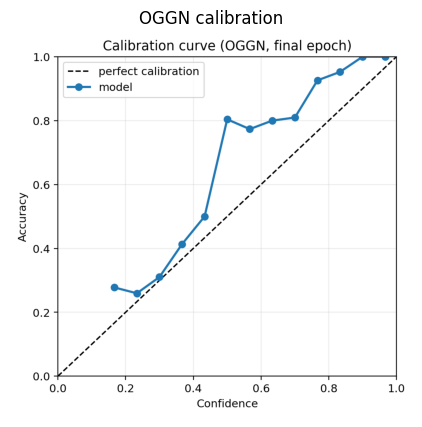

In [13]:
show_image('voggn_results/experiment6_calibration/calibration_curve_adam.png', 'Adam calibration')
show_image('voggn_results/experiment6_calibration/calibration_curve_vogn.png', 'VOGN calibration')
show_image('voggn_results/experiment6_calibration/calibration_curve_oggn.png', 'OGGN calibration')


### 2.5.4 ECE vs NLL


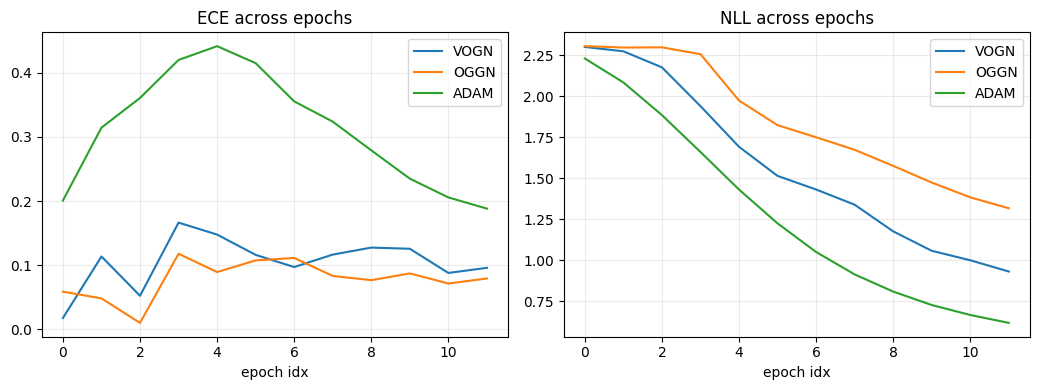

VOGN ECE start/end 0.017545176495407988 0.09580313635324661 | NLL start/end 2.301543512529614 0.9321525006454314
OGGN ECE start/end 0.05863192281276983 0.07916700080035874 | NLL start/end 2.3064439376729178 1.3177941759345957
ADAM ECE start/end 0.20080748964143616 0.18813999599875614 | NLL start/end 2.2313824873679113 0.6189055066157156


In [14]:
arr=np.load(p('voggn_results/experiment6_calibration/calibration_arrays.npz'))
fig,ax=plt.subplots(1,2,figsize=(10.5,4))
for m in ['vogn','oggn','adam']:
    ax[0].plot(arr[f'ece_{m}'],label=m.upper())
ax[0].set_title('ECE across epochs'); ax[0].set_xlabel('epoch idx'); ax[0].grid(alpha=0.25); ax[0].legend()
for m in ['vogn','oggn','adam']:
    ax[1].plot(arr[f'nll_{m}'],label=m.upper())
ax[1].set_title('NLL across epochs'); ax[1].set_xlabel('epoch idx'); ax[1].grid(alpha=0.25); ax[1].legend()
plt.tight_layout(); plt.show()

for m in ['vogn','oggn','adam']:
    e=np.array(arr[f'ece_{m}']); n=np.array(arr[f'nll_{m}'])
    print(m.upper(),'ECE start/end',float(e[0]),float(e[-1]),'| NLL start/end',float(n[0]),float(n[-1]))


## 2.6 Hyperparameter tuning


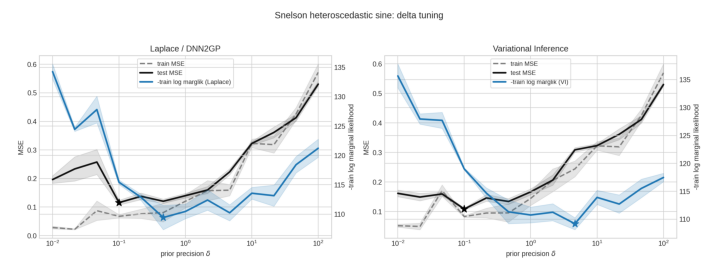

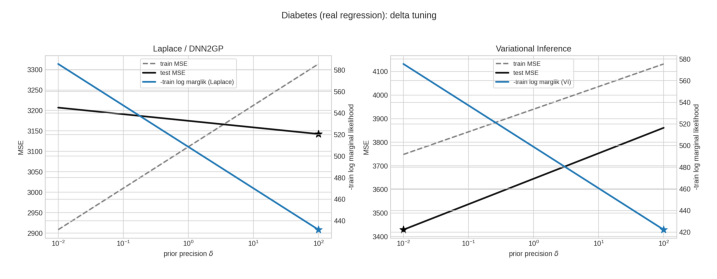

Synthetic run best deltas:
  Laplace test MSE min delta: 0.1
  Laplace marglik min delta: 0.46415888336127775
  VI test MSE min delta: 0.1
  VI marglik min delta: 4.6415888336127775

Real-data run best deltas:
  Laplace test MSE min delta: 100.0
  Laplace marglik min delta: 100.0
  VI test MSE min delta: 0.01
  VI marglik min delta: 100.0


In [15]:
# compare minima alignment from synthetic and real delta sweeps.
show_image('figures/marglik_delta_snelson_heteroscedastic_sine_delta_gpu_2h_vi.png')
show_image('figures/marglik_delta_diabetes_real_regression_smoke_real_delta.png')

with open(p('results/marglik_delta_gpu/delta_sweep_delta_gpu_2h_vi.json')) as f:
    syn=json.load(f)
print('Synthetic run best deltas:')
print('  Laplace test MSE min delta:', syn.get('best_delta_by_test_mse'))
print('  Laplace marglik min delta:', syn.get('best_delta_by_neg_train_marglik'))
print('  VI test MSE min delta:', syn.get('best_delta_by_test_mse_vi'))
print('  VI marglik min delta:', syn.get('best_delta_by_neg_train_marglik_vi'))

real_path = p('results/marglik_delta_real/delta_sweep_smoke_real_delta.json')
if real_path.exists():
    with open(real_path) as f:
        real=json.load(f)
    print('\nReal-data run best deltas:')
    print('  Laplace test MSE min delta:', real.get('best_delta_by_test_mse'))
    print('  Laplace marglik min delta:', real.get('best_delta_by_neg_train_marglik'))
    print('  VI test MSE min delta:', real.get('best_delta_by_test_mse_vi'))
    print('  VI marglik min delta:', real.get('best_delta_by_neg_train_marglik_vi'))
else:
    md('Real-data delta sweep JSON missing. Run `run_marglik_delta_real.py` to populate.')


#### Optional in-notebook run: delta tuning (small setup)


In [16]:
if RUN_ADDITIONAL_LIVE_EXPERIMENTS:
    import sys
    import numpy as np
    import torch
    from pathlib import Path

    if str(ROOT) not in sys.path:
        sys.path.insert(0, str(ROOT))

    from experiments.marglik_delta_gpu.run_marglik_delta_gpu import (
        SweepConfig,
        select_device,
        select_dtype,
        set_seed,
        evaluate_delta_once,
    )

    device_pref = "cuda" if USE_CUDA_IF_AVAILABLE and torch.cuda.is_available() else "cpu"
    device = select_device(device_pref)
    dtype = select_dtype("float32")

    cfg = SweepConfig(
        name="notebook_smoke",
        n_retries=1,
        n_train=60,
        n_test=240,
        n_params=2,
        delta_log10_min=-1.0,
        delta_log10_max=0.0,
        n_epochs=60,
        vi_epochs=20,
        include_vi=False,
        hidden_size=12,
        n_layers=1,
        activation="tanh",
        sigma_noise=1.0,
        sigma_low=0.1,
        sigma_high=1.0,
        p_middle=0.1,
        learning_rate=2e-2,
        lr_factor=0.995,
        seed=11,
        device=device_pref,
        dtype="float32",
        print_every=0,
        dataset_name="Snelson-style heteroscedastic sine (smoke)",
        output_dir=Path("results/marglik_delta_gpu"),
        figure_dir=Path("figures"),
    )

    set_seed(cfg.seed)
    deltas = [0.1, 0.464159]
    rows = []
    for i, d in enumerate(deltas):
        m = evaluate_delta_once(delta=float(d), dataset_seed=cfg.seed + i, cfg=cfg, device=device, dtype=dtype)
        rows.append((float(d), float(m["test_mse_map"]), float(-m["train_log_marglik"])))

    arr = np.array(rows)
    print("delta | test_mse | -train_marglik")
    for r in arr:
        print(f"{r[0]:.6f} | {r[1]:.5f} | {r[2]:.5f}")

    fig, ax1 = plt.subplots(figsize=(6.8, 4.2))
    ax1.plot(arr[:, 0], arr[:, 1], marker="o", color="tab:blue", label="test MSE")
    ax1.set_xscale("log")
    ax1.set_xlabel("delta")
    ax1.set_ylabel("test MSE", color="tab:blue")
    ax1.tick_params(axis="y", labelcolor="tab:blue")
    ax1.grid(alpha=0.25)

    ax2 = ax1.twinx()
    ax2.plot(arr[:, 0], arr[:, 2], marker="s", linestyle="--", color="tab:red", label="-train marglik")
    ax2.set_ylabel("-train marglik", color="tab:red")
    ax2.tick_params(axis="y", labelcolor="tab:red")

    plt.title("Delta in-notebook run (Laplace branch)")
    plt.tight_layout()
    plt.show()
else:
    print("Set RUN_ADDITIONAL_LIVE_EXPERIMENTS=True to execute this run.")


Set RUN_ADDITIONAL_LIVE_EXPERIMENTS=True to execute this run.


## Notebook usage

- The first live experiment (`MNIST 0/1` Laplace + DNN2GP) runs by default.
- Additional live experiments are disabled by default and can be enabled with `RUN_ADDITIONAL_LIVE_EXPERIMENTS = True`.
- Longer report experiments are loaded from saved artifacts in `results/`, `figures/`, and `voggn_results/`.
